In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('..\\data\\raw\\paysim.csv')

In [4]:
df_copy = df.copy()

In [5]:
df_copy.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df_copy.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [7]:
df_copy.shape

(6362620, 11)

In [8]:
df_copy['isFraud'].value_counts()[1]

np.int64(8213)

In [9]:
Fraud_Ratio = df_copy['isFraud'].value_counts()[1] / df_copy.shape[0] 
Fraud_Percentage = Fraud_Ratio * 100
Fraud_Percentage

np.float64(0.12908204481801522)

In [10]:
# 1. Confirm fraud is concentrated in TRANSFER/CASH_OUT only
fraud_by_type = df_copy.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type['fraud_rate_%'] = (fraud_by_type['sum'] / fraud_by_type['count']) * 100
print(fraud_by_type)

           sum    count  fraud_rate_%
type                                 
CASH_IN      0  1399284      0.000000
CASH_OUT  4116  2237500      0.183955
DEBIT        0    41432      0.000000
PAYMENT      0  2151495      0.000000
TRANSFER  4097   532909      0.768799


Important Inference

There are no Fraud detected on Cash_In, Debit and Payment
the fraud percentage is covered only by Cash out and Transfer category
which suggest that before fraud the fraudster cashes out the balance amount.



Transfer Has 4x higher fraude rate than Cash_out

So far considering this output Cash_In, Debit and Payment can be removed because they don't have any signficance towards training out model(they are just pure noise)

In [11]:
# 2. Naive baseline check — how good is the existing isFlaggedFraud rule?
from sklearn.metrics import precision_score, recall_score

precision = precision_score(df_copy['isFraud'], df_copy['isFlaggedFraud'])
recall = recall_score(df_copy['isFraud'], df_copy['isFlaggedFraud'])
print(f"Naive rule — Precision: {precision:.4f}, Recall: {recall:.4f}")

Naive rule — Precision: 1.0000, Recall: 0.0019


the naive rule (flag if TRANSFER > 200,000) is never wrong when it does flag something (100% precision) but it catches essentially nothing. Recall of 0.0019 means it catches less than 0.2% of all fraud out of 8,213 fraud transactions, this rule catches roughly 16 of them. 8,197 fraud transactions slip through completely.

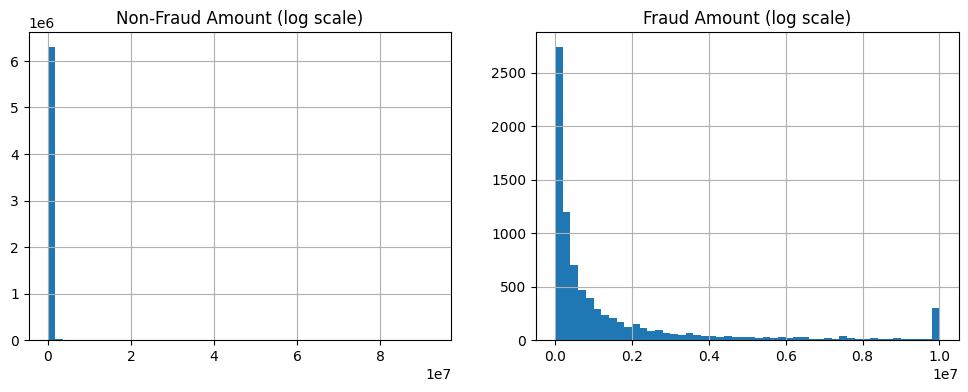

In [12]:
# 3. Amount distribution: fraud vs non-fraud (log scale, since amounts are skewed)
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_copy[df_copy['isFraud']==0]['amount'].hist(bins=50, ax=ax[0])
ax[0].set_title('Non-Fraud Amount (log scale)')
df_copy[df_copy['isFraud']==1]['amount'].hist(bins=50, ax=ax[1])
ax[1].set_title('Fraud Amount (log scale)')
plt.show()

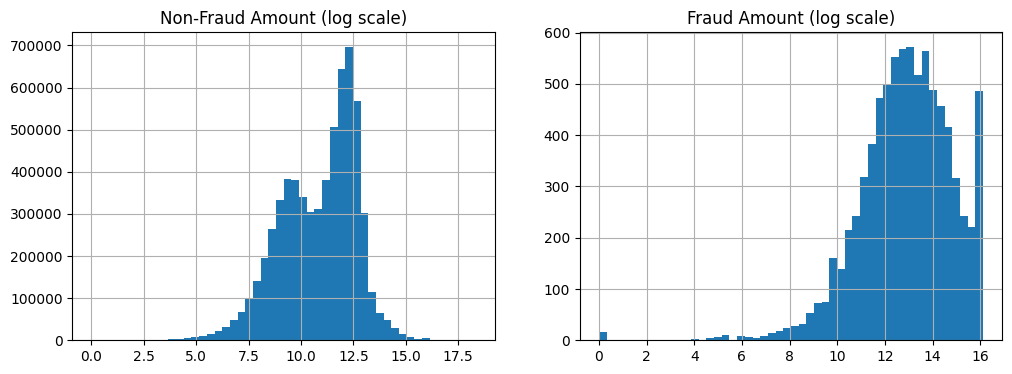

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_copy[df_copy['isFraud']==0]['amount'].apply(lambda x: np.log1p(x)).hist(bins=50, ax=ax[0])
ax[0].set_title('Non-Fraud Amount (log scale)')
df_copy[df_copy['isFraud']==1]['amount'].apply(lambda x: np.log1p(x)).hist(bins=50, ax=ax[1])
ax[1].set_title('Fraud Amount (log scale)')
plt.show()


comparing these two histograms, fraud amounts cluster much more heavily toward the high end (concentrated around 10-16 on the log scale, i.e., large transactions) compared to non-fraud, which spans a wider, more bimodal range.

Higher the transaction amount more prone to fraud

In [16]:
mask = df_copy['type'].isin(['TRANSFER', 'CASH_OUT'])
sub = df_copy[mask]

dest_zero = (sub['oldbalanceDest'] == 0) & (sub['newbalanceDest'] == 0) & (sub['amount'] > 0)
print("Dest-zero rate for fraud:", dest_zero[sub['isFraud']==1].mean())
print("Dest-zero rate for non-fraud:", dest_zero[sub['isFraud']==0].mean())

Dest-zero rate for fraud: 0.4955558261293072
Dest-zero rate for non-fraud: 0.0006176245277308345


49.6% of fraud transactions have a destination account that's completely untouched (zero before, zero after), versus only 0.06% of non-fraud transactions.

Why this pattern exists (the actual fraud mechanic, worth understanding not just memorizing): in roughly half the fraud cases, the "destination" account in PaySim is a dummy or improperly tracked account — money is transferred out of the victim's account, but the receiving side's balance was never properly recorded in the simulation

In [17]:
# New Feature: dest_balance_untouched
df_copy['dest_balance_untouched'] = (
    (df_copy['oldbalanceDest'] == 0) & 
    (df_copy['newbalanceDest'] == 0) & 
    (df_copy['amount'] > 0)
).astype(int)

In [18]:
df_copy.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_untouched
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1


In [21]:
txn_counts = df_copy['nameOrig'].value_counts()
txn_counts

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
              ..
C1970706589    1
C40604503      1
C1614818636    1
C2089752665    1
C154988899     1
Name: count, Length: 6353307, dtype: int64

In [ ]:
# how many transactions has this origin account made? (proxy for account age/activity)
txn_counts = df_copy['nameOrig'].value_counts()
df_copy['orig_txn_count'] = df_copy['nameOrig'].map(txn_counts)

print(df_copy.groupby('isFraud')['orig_txn_count'].describe())

             count      mean       std  min  25%  50%  75%  max
isFraud                                                        
0        6354407.0  1.002932  0.054195  1.0  1.0  1.0  1.0  3.0
1           8213.0  1.003409  0.058293  1.0  1.0  1.0  1.0  2.0


Since the data is Synthetic, Account Velocity doesn't contribute as a meaningful feature here

# Finalised Features

type (filtered to TRANSFER/CASH_OUT, then one-hot or label encoded)
amount

oldbalanceOrg, newbalanceOrig (raw — let the model find residual patterns)

oldbalanceDest, newbalanceDest (raw — needed to derive the next one, and may carry independent signal)

dest_balance_untouched (engineered — your strongest feature, 49.6% vs 0.06%)

In [22]:
df_copy.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'dest_balance_untouched', 'orig_txn_count'],
      dtype='object')

In [23]:
columns = ['nameOrig', 'nameDest', 'isFlaggedFraud','orig_txn_count','step']
df_copy.drop(columns=columns, inplace=True)

In [24]:
df_copy.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,dest_balance_untouched
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,1
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,1


In [25]:
# Droping rows of type 'Cash_IN' 'DEBIT' and 'PAYMENT' since they have no frauds

df_copy = df_copy[~df_copy['type'].isin(['CASH_IN', 'DEBIT', 'PAYMENT'])]

In [27]:
df_copy[df_copy['type'].isin(['CASH_IN', 'DEBIT', 'PAYMENT'])].shape

(0, 8)

In [28]:
df_copy.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,dest_balance_untouched
2,TRANSFER,181.00,181.0,0.0,0.0,0.00,1,1
3,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1,0
15,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0,0
19,TRANSFER,215310.30,705.0,0.0,22425.0,0.00,0,0
24,TRANSFER,311685.89,10835.0,0.0,6267.0,2719172.89,0,0
